# Benchmark 2 — `order_recognition.py`

This notebook is a **unit / integration benchmark** for the new order-recognition layer.

It does **not** require the full RG flow to be implemented yet.  Instead, it tests whether:

1. a `ChannelKernel` can be analyzed after channel decomposition,
2. nearly-degenerate subspaces are detected correctly,
3. generic template overlaps (`s/p/d/f`) work as expected,
4. the code reports clear limitations for multicomponent kagome orders.

Recommended usage inside your repo:
- put this notebook next to `form_factor.py`
- keep `channels.py` importable if available
- run all cells and inspect the printed summaries / plots


In [1]:
import numpy as np
from dataclasses import dataclass

from form_factor import OrderRecognizer

try:
    from channels import ChannelKernel
    print('Imported ChannelKernel from repo channels.py')
except Exception:
    @dataclass
    class ChannelKernel:
        name: str
        Q: np.ndarray
        matrix: np.ndarray
        row_patches: np.ndarray
        col_patches: np.ndarray
        row_partner_patches: np.ndarray
        col_partner_patches: np.ndarray
        row_spins: tuple
        col_spins: tuple
        residuals: np.ndarray
        def eig(self, sort_by='abs'):
            vals, vecs = np.linalg.eig(self.matrix)
            if sort_by == 'abs':
                order = np.argsort(-np.abs(vals))
            elif sort_by == 'real':
                order = np.argsort(-np.real(vals))
            else:
                raise ValueError
            return vals[order], vecs[:, order]
    print('Using local fallback ChannelKernel')

@dataclass
class FakePatch:
    k_cart: np.ndarray
    eigvec: np.ndarray

@dataclass
class FakePatchSet:
    patches: list
    b1: np.ndarray
    b2: np.ndarray
    @property
    def Npatch(self):
        return len(self.patches)


Imported ChannelKernel from repo channels.py


In [2]:
# Build a simple circular fake patch set with three-orbital kagome-like weights.
N = 24
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
ks = np.c_[np.cos(angles), np.sin(angles)]

patches = []
for th, k in zip(angles, ks):
    # Smoothly varying orbital dominance across the FS.
    w = np.array([
        0.55 + 0.35*np.cos(th),
        0.55 + 0.35*np.cos(th - 2*np.pi/3),
        0.55 + 0.35*np.cos(th - 4*np.pi/3),
    ])
    w = np.clip(w, 1e-6, None)
    u = np.sqrt(w / np.sum(w))
    patches.append(FakePatch(k_cart=k, eigvec=u.astype(complex)))

patchset = FakePatchSet(
    patches=patches,
    b1=np.array([2*np.pi, 0.0]),
    b2=np.array([0.0, 2*np.pi]),
)

recognizer = OrderRecognizer(patchset, degeneracy_tol=1e-8, projection_threshold=0.15)
print('Npatch =', patchset.Npatch)


Npatch = 24


In [3]:
def make_rank1_kernel(name, Q, vec, eigenvalue=10.0, partner=None):
    v = np.asarray(vec, dtype=complex)
    v = v / np.linalg.norm(v)
    M = eigenvalue * np.outer(v, np.conjugate(v))
    N = len(v)
    if partner is None:
        partner = np.arange(N, dtype=int)
    return ChannelKernel(
        name=name,
        Q=np.asarray(Q, dtype=float),
        matrix=M,
        row_patches=np.arange(N, dtype=int),
        col_patches=np.arange(N, dtype=int),
        row_partner_patches=np.asarray(partner, dtype=int),
        col_partner_patches=np.asarray(partner, dtype=int),
        row_spins=('x','x'),
        col_spins=('x','x'),
        residuals=np.zeros((N, N), dtype=float),
    )


def make_projector_kernel(name, Q, basis, eigenvalue=10.0, partner=None):
    B = np.column_stack([np.asarray(v, dtype=complex) / np.linalg.norm(v) for v in basis])
    Qr, _ = np.linalg.qr(B)
    M = eigenvalue * (Qr @ Qr.conjugate().T)
    N = Qr.shape[0]
    if partner is None:
        partner = np.arange(N, dtype=int)
    return ChannelKernel(
        name=name,
        Q=np.asarray(Q, dtype=float),
        matrix=M,
        row_patches=np.arange(N, dtype=int),
        col_patches=np.arange(N, dtype=int),
        row_partner_patches=np.asarray(partner, dtype=int),
        col_partner_patches=np.asarray(partner, dtype=int),
        row_spins=('x','x'),
        col_spins=('x','x'),
        residuals=np.zeros((N, N), dtype=float),
    )

partner_pp = (np.arange(N) + N//2) % N


## Test 1 — Q = 0 particle-hole nematic / d-wave doublet

This test mimics the paper's **Pomeranchuk instability** logic: `Q = 0`, particle-hole channel,
and a **two-dimensional d-wave-like subspace**.


In [4]:
v_d1 = np.cos(2*angles)
v_d2 = np.sin(2*angles)
kernel_pi = make_projector_kernel('ph_direct', [0.0, 0.0], [v_d1, v_d2], eigenvalue=12.0)
analyses_pi = recognizer.analyze_kernel(kernel_pi, n_groups=2)

for i, an in enumerate(analyses_pi):
    print(f'Group {i}:', an.summary_dict())
    print('Top template scores:', [(p.name, round(p.score, 4)) for p in an.projections[:5]])
    print('-'*80)


Group 0: {'kernel': 'ph_direct', 'Q': [0.0, 0.0], 'subspace_dim': 2, 'dominant_label': 'd', 'dominant_score': 1.0000000000000002, 'eigenvalues': [(12.000000000000005+0j), (12.000000000000002+0j)], 'partner_parity': None, 'notes': ['Q≈0 particle-hole mode: candidate Pomeranchuk / nematic sector.', 'Leading space is at least two-dimensional; treat it as an irrep subspace, not one fixed basis vector.', 'Particle-hole patch harmonics can diagnose Q and rough lattice symmetry, but real-space bond-order identification still needs a separate bond/sublattice reconstruction layer.'], 'sublattice_weights': [0.33333333333333337, 0.33333333333333337, 0.33333333333333337], 'dominant_sublattice': 0}
Top template scores: [('d', 1.0), ('ph_nematic', 1.0), ('paper_d_Q0', 0.9908), ('f', 0.0), ('p', 0.0)]
--------------------------------------------------------------------------------
Group 1: {'kernel': 'ph_direct', 'Q': [0.0, 0.0], 'subspace_dim': 22, 'dominant_label': 'p', 'dominant_score': 1.00000000

Expected result:
- the leading subspace should have dimension 2,
- the dominant label should be close to `d`, `paper_d_Q0`, or `ph_nematic`,
- the notes should say this is a **Q≈0 particle-hole candidate Pomeranchuk / nematic sector**.


## Test 2 — finite-Q particle-hole bond-order-like pattern

This is a coarse benchmark for a **finite-Q particle-hole** mode. It does **not** reconstruct
real-space cBO/sBO bonds yet, but the recognizer should at least tell you that this sits in a
finite-Q particle-hole sector and has strong overlap with cosine/sine templates at that `Q`.


In [5]:
Q_test = np.array([1.2, -0.7])
phase = ks @ Q_test
v_bo = np.cos(phase) + 0.25*np.sin(2*phase)
kernel_bo = make_rank1_kernel('ph_crossed', Q_test, v_bo, eigenvalue=8.0)
analyses_bo = recognizer.analyze_kernel(kernel_bo, n_groups=2)

for i, an in enumerate(analyses_bo):
    print(f'Group {i}:', an.summary_dict())
    print('Top template scores:', [(p.name, round(p.score, 4)) for p in an.projections[:5]])
    print('-'*80)


Group 0: {'kernel': 'ph_crossed', 'Q': [1.2, -0.7], 'subspace_dim': 1, 'dominant_label': 'finiteQ_cos_sin', 'dominant_score': 0.9848650973000208, 'eigenvalues': [(7.999999999999996+0j)], 'partner_parity': None, 'notes': ['Finite-Q particle-hole mode: candidate bond / density-wave sector.', 'Particle-hole patch harmonics can diagnose Q and rough lattice symmetry, but real-space bond-order identification still needs a separate bond/sublattice reconstruction layer.'], 'sublattice_weights': [0.3760107429916593, 0.2904347912939387, 0.33355446571440206], 'dominant_sublattice': 0}
Top template scores: [('finiteQ_cos_sin', 0.9849), ('s', 0.7407), ('f', 0.1868), ('paper_d_Q0', 0.186), ('d', 0.1782)]
--------------------------------------------------------------------------------
Group 1: {'kernel': 'ph_crossed', 'Q': [1.2, -0.7], 'subspace_dim': 23, 'dominant_label': 'p', 'dominant_score': 0.9185033592464429, 'eigenvalues': [(1.6675873235233523e-16+1.9768652934875884e-16j), (1.6675873235233528e

## Test 3 — particle-particle odd-parity / f-wave-like mode

This test checks the superconducting side.  We use a simple odd-parity patch mode built from
`cos(3θ)` and provide a partner map `p -> Q - p` on the toy circular FS.


In [6]:
v_f = np.cos(3*angles)
kernel_f = make_rank1_kernel('pp_triplet_sz0', [0.0, 0.0], v_f, eigenvalue=9.0, partner=partner_pp)
analyses_f = recognizer.analyze_kernel(kernel_f, n_groups=2)

for i, an in enumerate(analyses_f):
    print(f'Group {i}:', an.summary_dict())
    print('Top template scores:', [(p.name, round(p.score, 4)) for p in an.projections[:5]])
    print('-'*80)


Group 0: {'kernel': 'pp_triplet_sz0', 'Q': [0.0, 0.0], 'subspace_dim': 1, 'dominant_label': 'f', 'dominant_score': 1.0000000000000009, 'eigenvalues': [(9.000000000000004+0j)], 'partner_parity': -1.0, 'notes': ['Particle-particle mode: candidate superconducting sector.', "Patch-space scalar harmonics can diagnose even/odd and approximate angular momentum, but do not by themselves reconstruct the paper's full sublattice-pair f-wave tensor structure."], 'sublattice_weights': [0.33333333333333337, 0.3333333333333333, 0.3333333333333334], 'dominant_sublattice': 2}
Top template scores: [('f', 1.0), ('pp_odd', 1.0), ('p', 0.0), ('d', 0.0), ('pp_even', 0.0)]
--------------------------------------------------------------------------------
Group 1: {'kernel': 'pp_triplet_sz0', 'Q': [0.0, 0.0], 'subspace_dim': 23, 'dominant_label': 'p', 'dominant_score': 1.0000000000000002, 'eigenvalues': [(5.389973626952019e-16+0j), (4.2518304777254294e-16+0j), (-3.8673374864347364e-16+0j), (-1.7914914272187657e

Expected result:
- dominant label should be close to `f` or `pp_odd`,
- `partner_parity` should be negative for an odd mode,
- notes should explicitly warn that this is only a **patch-space diagnosis**, not the full kagome
  sublattice-pair reconstruction of the paper's f-wave SC order.


## Test 4 — intentionally novel / unclassified mode

Here we feed in a random mode that should not project strongly onto the default templates.
This is the important **future-proofing** benchmark: the code should not force every mode into
`s/p/d/f` if the overlap is weak.


In [7]:
rng = np.random.default_rng(1234)
v_rand = rng.normal(size=N) + 1j * rng.normal(size=N)
kernel_rand = make_rank1_kernel('ph_direct', [0.3, 0.15], v_rand, eigenvalue=5.0)
analyses_rand = recognizer.analyze_kernel(kernel_rand, n_groups=1)
for an in analyses_rand:
    print(an.summary_dict())
    print('Top template scores:', [(p.name, round(p.score, 4)) for p in an.projections[:5]])


{'kernel': 'ph_direct', 'Q': [0.3, 0.15], 'subspace_dim': 1, 'dominant_label': 'unclassified', 'dominant_score': 0.10561418901575287, 'eigenvalues': [(4.999999999999999-5.60074428158017e-17j)], 'partner_parity': None, 'notes': ['Finite-Q particle-hole mode: candidate bond / density-wave sector.', 'Particle-hole patch harmonics can diagnose Q and rough lattice symmetry, but real-space bond-order identification still needs a separate bond/sublattice reconstruction layer.', 'No template family has strong overlap; keep this mode as numerically discovered / potentially novel.'], 'sublattice_weights': [0.31547193358059, 0.3478153751397851, 0.33671269127962494], 'dominant_sublattice': 1}
Top template scores: [('finiteQ_cos_sin', 0.1056), ('p', 0.0595), ('s', 0.058), ('d', 0.0558), ('ph_nematic', 0.0558)]


## Quick visualization


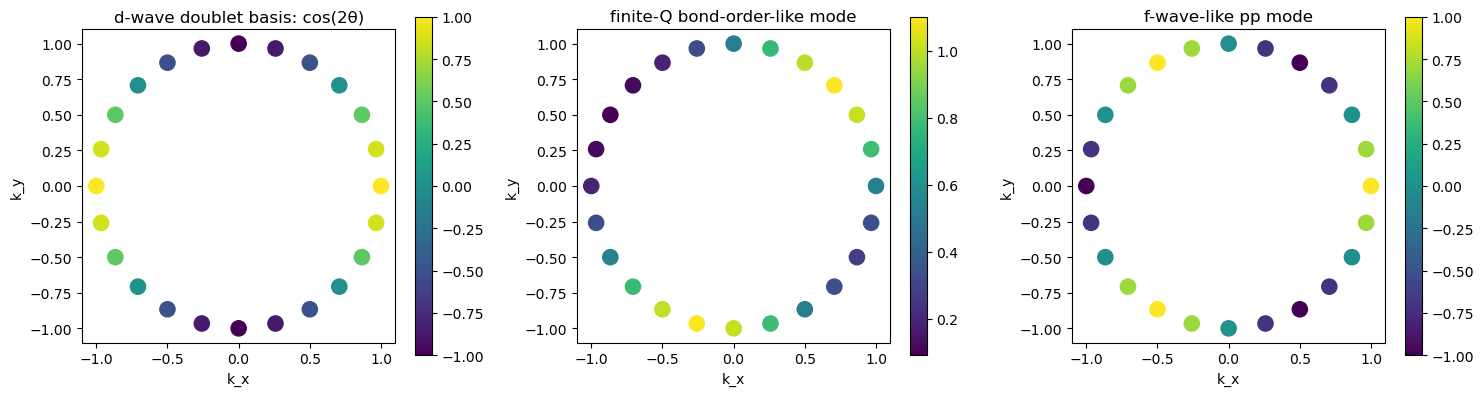

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, title, vec in [
    (axes[0], 'd-wave doublet basis: cos(2θ)', v_d1),
    (axes[1], 'finite-Q bond-order-like mode', v_bo),
    (axes[2], 'f-wave-like pp mode', v_f),
]:
    sc = ax.scatter(ks[:,0], ks[:,1], c=np.real(vec), s=120)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('k_x')
    ax.set_ylabel('k_y')
    fig.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()


## What this notebook validates

If all cells run and the outputs look sensible, then your new module is already doing the **right layer of work**:

- it reads a post-channel-decomposition kernel,
- it detects leading / degenerate mode structure,
- it gives a symmetry-oriented label without hardwiring the answer,
- and it clearly says when the mode should remain **unclassified** or when a **paper-specific bond reconstruction** is still needed.

That is exactly what you want before the full FRG flow is written.
